# Задача 3
Call-центр с переменной нагрузкой

In [51]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# параметры
Q = np.array([[-0.3, 0.2, 0.1],
              [0.1, -0.2, 0.1],
              [0.2, 0.3, -0.5]])

lam = [0.2, 0.5, 0.1]  # утро, день, вечер
mu = 0.4  # обслуживание
servers = 3
queue_max = 2
sim_time = 2000

np.random.seed(42)

In [52]:
# генерируем события марковского потока
def gen_mar():
    state = 0
    t = 0
    events = []
    
    while t < sim_time:
        # выход из состояния
        exit_rate = -Q[state, state]
        tau = np.random.exponential(1 / exit_rate)
        t += tau
        
        if t >= sim_time:
            break
        
        # прибытие или переход?
        if np.random.random() < lam[state] / exit_rate:
            events.append(t)
        else:
            # смена состояния
            trans = Q[state] / exit_rate
            trans[state] = 0
            state = np.random.choice(3, p=trans/trans.sum())
    
    return np.array(events)

arrivals = gen_mar()
print(f'Всего поступило {len(arrivals)} звонков')

Всего поступило 431 звонков


In [53]:
# симуляция системы
busy = 0  # занятых операторов
queue = []  # очередь
service_ends = []  # когда заканчивается обслуживание

wait_times = []
lost = 0
served = 0
busy_all_time = 0
last_change = 0
was_full = False

for arrival in arrivals:
    # обработаем завершения обслуживания до этого момента
    while service_ends and service_ends[0] <= arrival:
        end = service_ends.pop(0)
        
        if busy == servers and was_full:
            busy_all_time += end - last_change
            was_full = False
        
        busy -= 1
        last_change = end
        
        # возьми из очереди
        if queue:
            arr_t = queue.pop(0)
            wait_times.append(end - arr_t)
            service_ends.append(end + np.random.exponential(1/mu))
            service_ends.sort()
            busy += 1
            served += 1
    
    # новый звонок
    if busy < servers:
        if busy == servers - 1:
            was_full = True
            last_change = arrival
        service_ends.append(arrival + np.random.exponential(1/mu))
        service_ends.sort()
        busy += 1
        served += 1
    elif len(queue) < queue_max:
        queue.append(arrival)
    else:
        lost += 1

print(f'Обслужено: {served}')
print(f'Потеряно: {lost}')
print(f'В очереди: {len(queue)}')
print(f'Среднее время ожидания: {np.mean(wait_times):.4f}' if wait_times else 'Нет ожидания')
print(f'Доля времени все операторы заняты: {busy_all_time/sim_time:.4f}')

Обслужено: 430
Потеряно: 1
В очереди: 0
Среднее время ожидания: 0.9091
Доля времени все операторы заняты: 0.0180


In [54]:
# результаты
print('='*50)
print('РЕЗУЛЬТАТЫ')
print('='*50)
print(f'1. Среднее время ожидания: {np.mean(wait_times):.4f} единиц' if wait_times else '1. Нет ожидания')
print(f'2. Потерянных звонков: {lost} ({100*lost/len(arrivals):.2f}%)')
print(f'3. Доля времени все операторы заняты: {busy_all_time/sim_time:.4f} ({100*busy_all_time/sim_time:.2f}%)')
print('='*50)

РЕЗУЛЬТАТЫ
1. Среднее время ожидания: 0.9091 единиц
2. Потерянных звонков: 1 (0.23%)
3. Доля времени все операторы заняты: 0.0180 (1.80%)


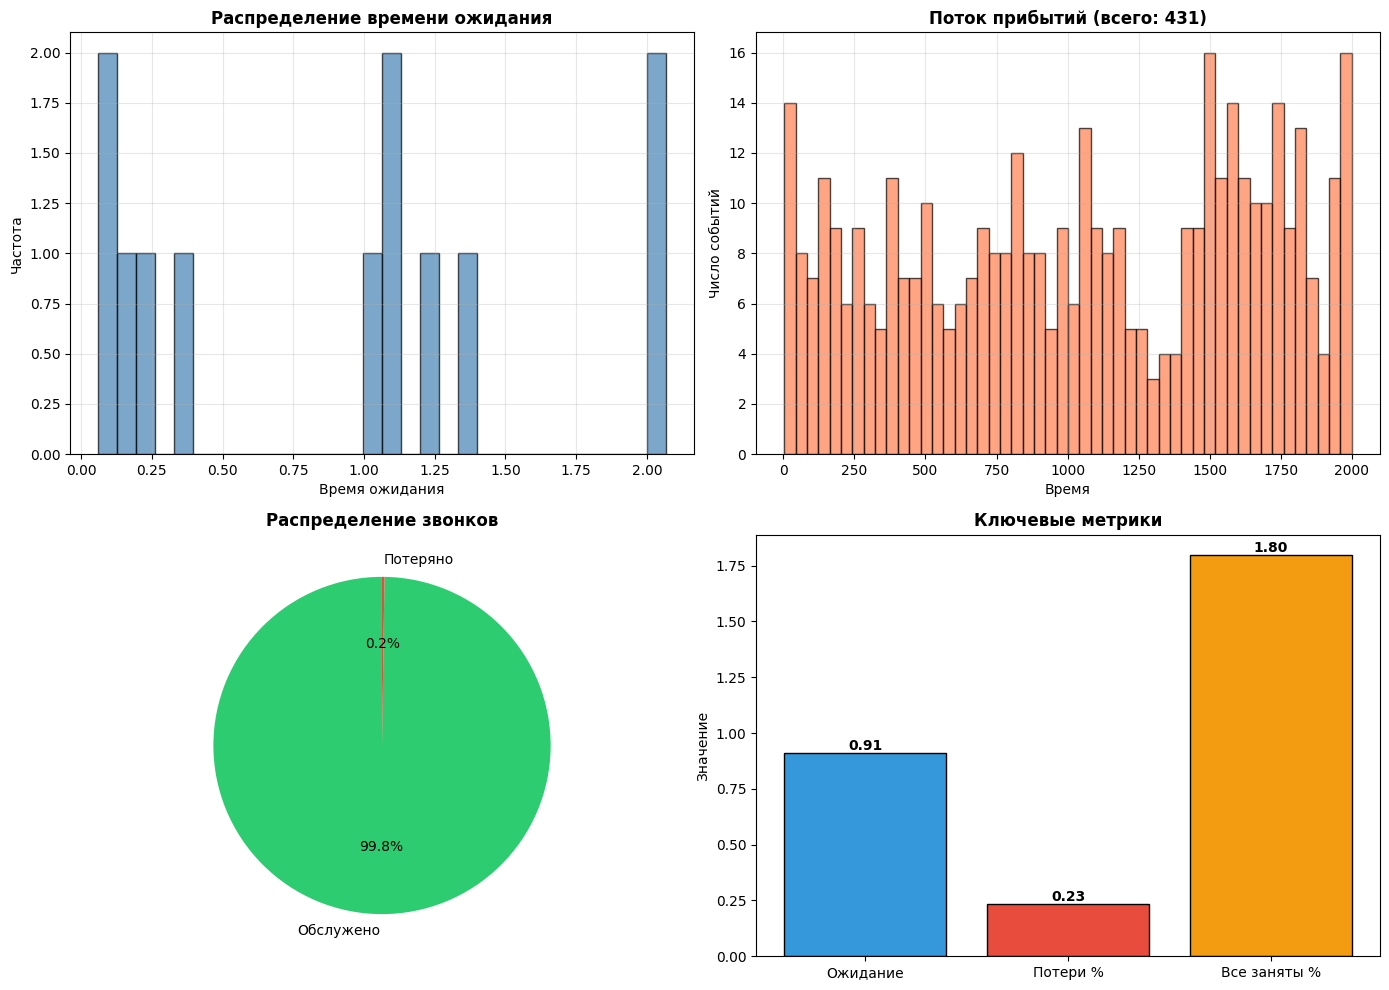


Графики сохранены!


In [55]:
# графики для красоты
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. распределение времени ожидания
if wait_times:
    axes[0, 0].hist(wait_times, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[0, 0].set_title('Распределение времени ожидания', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Время ожидания')
    axes[0, 0].set_ylabel('Частота')
    axes[0, 0].grid(True, alpha=0.3)

# 2. поток прибытий
axes[0, 1].hist(arrivals, bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[0, 1].set_title(f'Поток прибытий (всего: {len(arrivals)})', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Время')
axes[0, 1].set_ylabel('Число событий')
axes[0, 1].grid(True, alpha=0.3)

# 3. статистика
labels = ['Обслужено', 'Потеряно']
sizes = [served, lost]
colors = ['#2ecc71', '#e74c3c']
axes[1, 0].pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1, 0].set_title('Распределение звонков', fontsize=12, fontweight='bold')

# 4. метрики
metrics = ['Ожидание', 'Потери %', 'Все заняты %']
values = [np.mean(wait_times) if wait_times else 0, 100*lost/len(arrivals), 100*busy_all_time/sim_time]
bars = axes[1, 1].bar(metrics, values, color=['#3498db', '#e74c3c', '#f39c12'], edgecolor='black')
axes[1, 1].set_title('Ключевые метрики', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Значение')
for bar, val in zip(bars, values):
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('callcenter_results.png', dpi=100, bbox_inches='tight')
plt.show()

print('\nГрафики сохранены!')